Install Libraries

In [ ]:
!pip install -q opencv-python
!pip install -q albumentations

Import Libraries

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

Load Dataset

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

dataset = os.path.join(dataset_path,"chest_xray")

train_path = os.path.join(dataset,"train")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


Read One Image

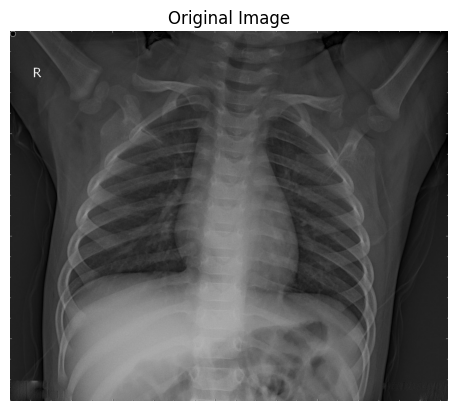

In [ ]:
normal_folder = os.path.join(train_path,"NORMAL")

image_name = os.listdir(normal_folder)[0]

image_path = os.path.join(normal_folder,image_name)

image = cv2.imread(image_path)

image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

Check Image Shape

In [ ]:
print(image.shape)

(1128, 1336, 3)


Resize Image

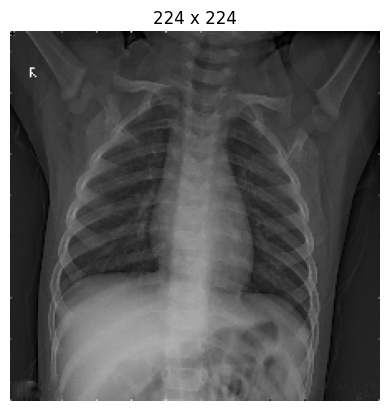

In [ ]:
IMG_SIZE = 224

resized = cv2.resize(image,(IMG_SIZE,IMG_SIZE))

plt.imshow(resized)
plt.title("224 x 224")
plt.axis("off")
plt.show()

Convert to Grayscale

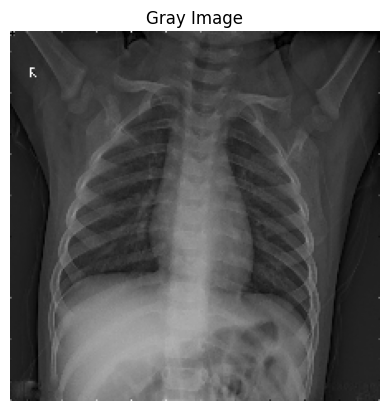

In [ ]:
gray = cv2.cvtColor(resized,cv2.COLOR_RGB2GRAY)

plt.imshow(gray,cmap="gray")
plt.title("Gray Image")
plt.axis("off")
plt.show()

Apply CLAHE

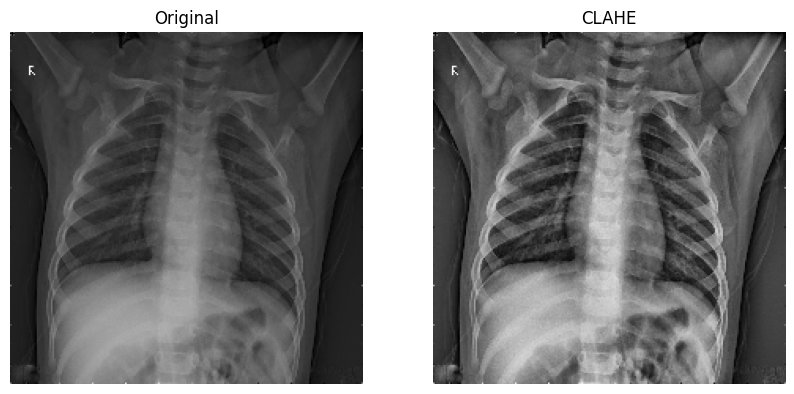

In [ ]:
clahe = cv2.createCLAHE(

clipLimit=2.0,

tileGridSize=(8,8)

)

clahe_image = clahe.apply(gray)

plt.figure(figsize=(10,5))

plt.subplot(121)

plt.imshow(gray,cmap="gray")

plt.title("Original")

plt.axis("off")

plt.subplot(122)

plt.imshow(clahe_image,cmap="gray")

plt.title("CLAHE")

plt.axis("off")

plt.show()

Noise Removal

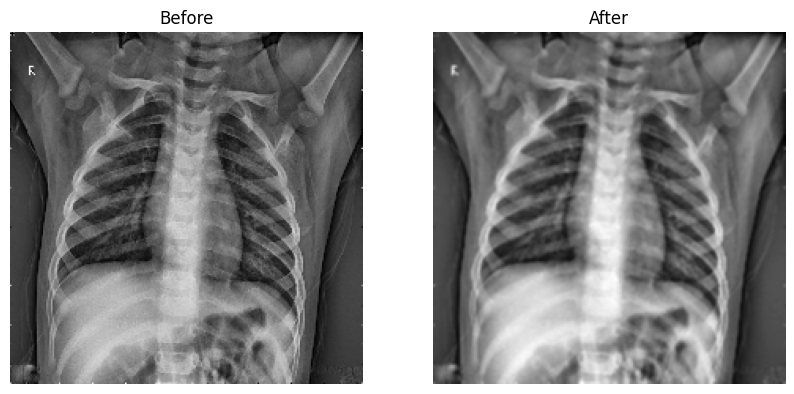

In [ ]:
denoise = cv2.GaussianBlur(

clahe_image,

(3,3),

0

)

plt.figure(figsize=(10,5))

plt.subplot(121)

plt.imshow(clahe_image,cmap="gray")

plt.title("Before")

plt.axis("off")

plt.subplot(122)

plt.imshow(denoise,cmap="gray")

plt.title("After")

plt.axis("off")

plt.show()

Median Filter

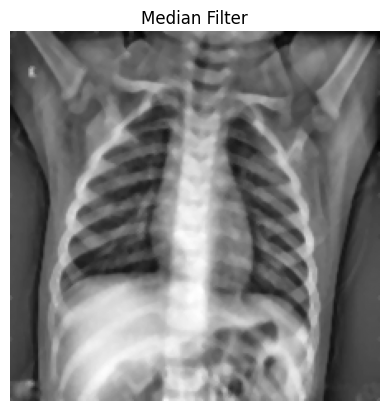

In [ ]:
median = cv2.medianBlur(

denoise,

3

)

plt.imshow(median,cmap="gray")
plt.title("Median Filter")
plt.axis("off")
plt.show()

Normalize Pixel Values

In [ ]:
normalized = median / 255.0

print(normalized.min())
print(normalized.max())

0.01568627450980392
0.8235294117647058


Histogram

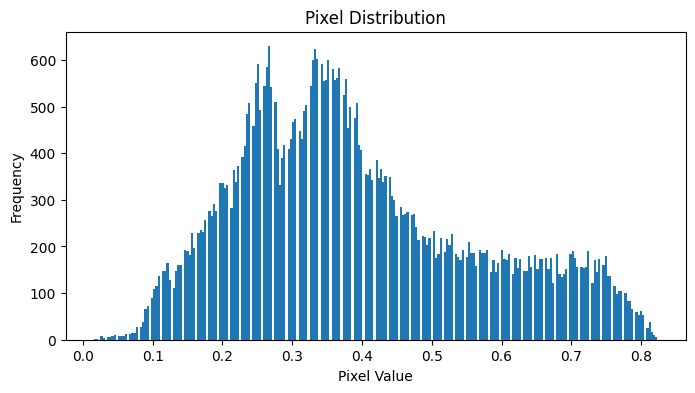

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(normalized.ravel(),256)

plt.title("Pixel Distribution")

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")

plt.show()

Display All Steps Together

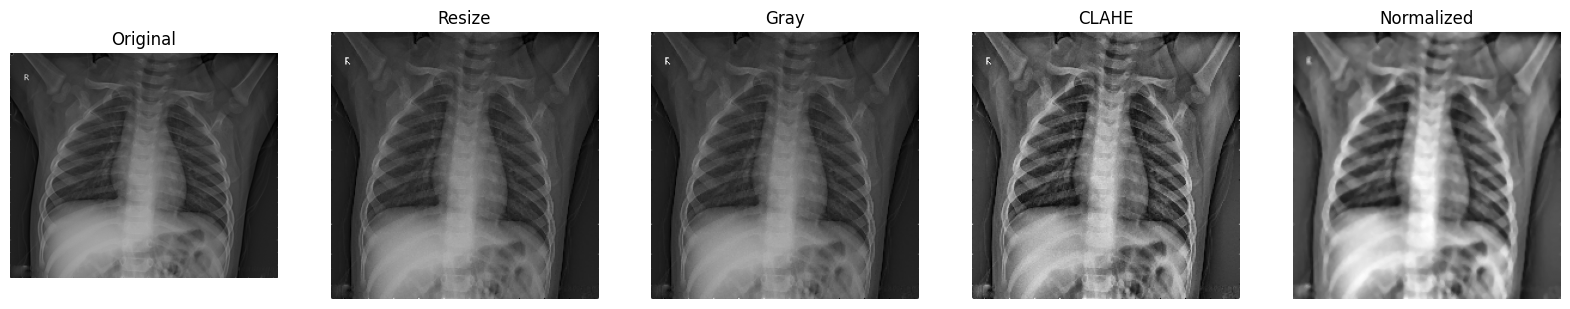

In [ ]:
fig,ax = plt.subplots(1,5,figsize=(20,5))

ax[0].imshow(image)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(resized)
ax[1].set_title("Resize")
ax[1].axis("off")

ax[2].imshow(gray,cmap="gray")
ax[2].set_title("Gray")
ax[2].axis("off")

ax[3].imshow(clahe_image,cmap="gray")
ax[3].set_title("CLAHE")
ax[3].axis("off")

ax[4].imshow(normalized,cmap="gray")
ax[4].set_title("Normalized")
ax[4].axis("off")

plt.show()

Create Preprocessing Function

In [ ]:
def preprocess_image(path, img_size=224):

    image = cv2.imread(path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (img_size, img_size))

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    gray = clahe.apply(gray)

    gray = cv2.GaussianBlur(gray, (3,3), 0)

    gray = gray / 255.0

    return gray

Test the Function

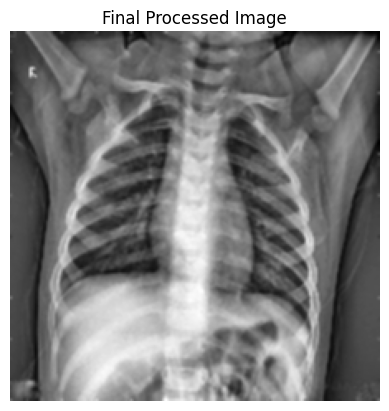

In [ ]:
processed = preprocess_image(image_path)

plt.imshow(processed,cmap="gray")
plt.title("Final Processed Image")
plt.axis("off")
plt.show()

Process an Entire Folder

In [ ]:
processed_images = []

labels = []

for cls in ["NORMAL","PNEUMONIA"]:

    folder = os.path.join(train_path, cls)

    for img in os.listdir(folder):

        path = os.path.join(folder, img)

        try:

            image = preprocess_image(path)

            processed_images.append(image)

            labels.append(cls)

        except Exception:

            pass

print("Processed Images :", len(processed_images))

Processed Images : 5216


Convert to NumPy Arrays

In [ ]:
X = np.array(processed_images)

y = np.array(labels)

print(X.shape)
print(y.shape)

(5216, 224, 224)
(5216,)


Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(np.unique(y))

[0 1]


Save Preprocessed Data

In [ ]:
np.save("X_train.npy", X)
np.save("y_train.npy", y)